# Latent Readout And Rollout Sweep Summary

Compact cached-results notebook for supervisor-facing plots. It loads CSV exports only and summarizes each dataset separately. The current report filters out 100-frames-per-network configurations.

Metrics shown:

1. Initial latent coordinates as a readout of final p-ratio.
2. Autoregressive rollout p-ratio R2 over 10..100 rollout steps.
3. Autoregressive rollout position MSE, capped and shown on a log scale so catastrophic failures do not hide the useful small-error range.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 250,
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.24,
})

base_results = Path('../results/latent_space_capacity_sweep/full_sweep')
if not (base_results / 'exports').exists():
    base_results = Path('notebooks/results/latent_space_capacity_sweep/full_sweep')
export_dir = base_results / 'exports'

initial_run_path = export_dir / 'initial_latent_pratio_readout_by_run.csv'
rollout_run_path = export_dir / 'sweep_rollout_stats.csv'

initial_runs = pd.read_csv(initial_run_path)
rollout_runs = pd.read_csv(rollout_run_path)

excluded_train_frames_per_network = {100}
if excluded_train_frames_per_network:
    initial_before = len(initial_runs)
    rollout_before = len(rollout_runs)
    initial_runs = initial_runs[~initial_runs['train_frames_per_network'].isin(excluded_train_frames_per_network)].copy()
    rollout_runs = rollout_runs[~rollout_runs['train_frames_per_network'].isin(excluded_train_frames_per_network)].copy()
    print(
        'excluded train_frames_per_network:',
        sorted(excluded_train_frames_per_network),
        f'initial rows {initial_before} -> {len(initial_runs)};',
        f'rollout rows {rollout_before} -> {len(rollout_runs)}',
    )

factors = ['latent_dim', 'train_networks', 'train_frames_per_network']
plot_specs = [
    ('latent_dim', 'CV count'),
    ('train_networks', 'Training networks'),
    ('train_frames_per_network', 'Frames / network'),
]
dataset_order = [d for d in ['reid', 'depablo'] if d in set(rollout_runs['dataset_name'])]
dataset_labels = {'reid': 'Reid', 'depablo': 'de Pablo'}

mse_plot_floor = 1e-8
mse_plot_cap = 1e-4

print('exports:', export_dir)
print('initial readout rows:', initial_runs.shape)
print('rollout rows:', rollout_runs.shape)
print('datasets:', dataset_order)



excluded train_frames_per_network: [100] initial rows 90 -> 90; rollout rows 990 -> 990
exports: results/latent_space_capacity_sweep/full_sweep/exports
initial readout rows: (90, 13)
rollout rows: (990, 20)
datasets: ['depablo']


In [2]:
# Aggregate initial latent -> final p-ratio readout by config and dataset.
# combo_test_r2 is the test R2 after fitting a linear CV combination on validation.
initial_summary = (
    initial_runs
    .groupby(['dataset_name', 'target_mode'] + factors, as_index=False)
    .agg(
        combo_test_r2_mean=('combo_test_r2', 'mean'),
        combo_test_r2_std=('combo_test_r2', 'std'),
        single_test_r2_mean=('single_test_r2', 'mean'),
        single_test_r2_std=('single_test_r2', 'std'),
        n_repeats=('repeat_idx', 'nunique'),
    )
)

# Aggregate rollout metrics from per-repeat rows, then summarize each config over steps 10..100.
rollout_runs = rollout_runs.copy()
rollout_runs['rollout_p_ratio_r2_clipped'] = rollout_runs['p_ratio_r2'].clip(lower=0)
rollout_runs['position_mse_plot'] = rollout_runs['final_pos_mse'].clip(lower=mse_plot_floor, upper=mse_plot_cap)

rollout_step_summary = (
    rollout_runs
    .groupby(['dataset_name', 'target_mode'] + factors + ['rollout_steps'], as_index=False)
    .agg(
        rollout_p_ratio_r2_mean=('p_ratio_r2', 'mean'),
        rollout_p_ratio_r2_std=('p_ratio_r2', 'std'),
        rollout_p_ratio_r2_clipped_mean=('rollout_p_ratio_r2_clipped', 'mean'),
        rollout_position_mse_mean=('final_pos_mse', 'mean'),
        rollout_position_mse_plot_mean=('position_mse_plot', 'mean'),
        n_repeats=('repeat_idx', 'nunique'),
        used=('used', 'mean'),
    )
)

rollout_config_summary = (
    rollout_step_summary
    .groupby(['dataset_name', 'target_mode'] + factors, as_index=False)
    .agg(
        mean_rollout_r2=('rollout_p_ratio_r2_mean', 'mean'),
        mean_rollout_r2_clipped=('rollout_p_ratio_r2_clipped_mean', 'mean'),
        min_rollout_r2=('rollout_p_ratio_r2_mean', 'min'),
        mean_position_mse=('rollout_position_mse_mean', 'mean'),
        mean_position_mse_plot=('rollout_position_mse_plot_mean', 'mean'),
        n_repeats=('n_repeats', 'min'),
    )
)

step50 = rollout_step_summary[rollout_step_summary['rollout_steps'].eq(50)][
    ['dataset_name', 'target_mode'] + factors + ['rollout_p_ratio_r2_mean', 'rollout_position_mse_mean', 'rollout_position_mse_plot_mean']
].rename(columns={
    'rollout_p_ratio_r2_mean': 'step50_rollout_r2',
    'rollout_position_mse_mean': 'step50_position_mse',
    'rollout_position_mse_plot_mean': 'step50_position_mse_plot',
})
step100 = rollout_step_summary[rollout_step_summary['rollout_steps'].eq(100)][
    ['dataset_name', 'target_mode'] + factors + ['rollout_p_ratio_r2_mean', 'rollout_position_mse_mean', 'rollout_position_mse_plot_mean']
].rename(columns={
    'rollout_p_ratio_r2_mean': 'step100_rollout_r2',
    'rollout_position_mse_mean': 'step100_position_mse',
    'rollout_position_mse_plot_mean': 'step100_position_mse_plot',
})
rollout_config_summary = rollout_config_summary.merge(step50, on=['dataset_name', 'target_mode'] + factors, how='left').merge(
    step100, on=['dataset_name', 'target_mode'] + factors, how='left'
)

print('Initial readout repeat coverage')
initial_coverage = initial_summary.groupby('dataset_name')['n_repeats'].agg(['count', 'min', 'max'])
display(initial_coverage)
if (initial_coverage['min'] < 3).any():
    print('Note: initial latent readout uses whatever cached scan exists. Rerun/refresh the initial readout scan if you need 3-repeat initial readout for every dataset.')
print('Rollout repeat coverage')
display(rollout_config_summary.groupby('dataset_name')['n_repeats'].agg(['count', 'min', 'max']))


Initial readout repeat coverage


,count,min,max
dataset_name,,,
depablo,30,3,3


Rollout repeat coverage


,count,min,max
dataset_name,,,
depablo,30,3,3


In [3]:
def additive_factor_report(df, metric, factors):
    def lin_r2(X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        X = np.column_stack([np.ones(len(X)), X])
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        pred = X @ beta
        ss_res = float(((y - pred) ** 2).sum())
        ss_tot = float(((y - y.mean()) ** 2).sum())
        return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    rows = []
    for dataset_name, group in df.groupby('dataset_name'):
        clean = group.dropna(subset=[metric]).copy()
        if len(clean) < 4:
            continue
        y = clean[metric].to_numpy(dtype=float)
        Xfull = pd.get_dummies(clean[factors].astype(str), drop_first=False).astype(float)
        full_r2 = lin_r2(Xfull.to_numpy(), y)
        rows.append({'dataset_name': dataset_name, 'factor': 'full additive model', 'unique_r2': np.nan, 'model_r2': full_r2})
        for factor in factors:
            cols = [c for c in Xfull.columns if not c.startswith(factor + '_')]
            without_r2 = lin_r2(Xfull[cols].to_numpy(), y)
            rows.append({'dataset_name': dataset_name, 'factor': factor, 'unique_r2': full_r2 - without_r2, 'model_r2_without_factor': without_r2})
    return pd.DataFrame(rows)

factor_reports = {
    'initial_combo_r2': additive_factor_report(initial_summary, 'combo_test_r2_mean', factors),
    'rollout_pratio_r2': additive_factor_report(rollout_config_summary, 'mean_rollout_r2_clipped', factors),
    'rollout_position_mse_plot': additive_factor_report(rollout_config_summary, 'mean_position_mse_plot', factors),
}

for name, report in factor_reports.items():
    print(name)
    display(report.round(4))


initial_combo_r2


,dataset_name,factor,unique_r2,model_r2,model_r2_without_factor
0,depablo,full additive model,NaN,0.4485,NaN
1,depablo,latent_dim,0.3107,NaN,0.1378
2,depablo,train_networks,0.1378,NaN,0.3107
3,depablo,train_frames_per_network,-0.0000,NaN,0.4485


rollout_pratio_r2


,dataset_name,factor,unique_r2,model_r2,model_r2_without_factor
0,depablo,full additive model,NaN,0.844,NaN
1,depablo,latent_dim,0.0996,NaN,0.7443
2,depablo,train_networks,0.7443,NaN,0.0996
3,depablo,train_frames_per_network,-0.0000,NaN,0.8440


rollout_position_mse_plot


,dataset_name,factor,unique_r2,model_r2,model_r2_without_factor
0,depablo,full additive model,NaN,0.9398,NaN
1,depablo,latent_dim,0.0710,NaN,0.8688
2,depablo,train_networks,0.8688,NaN,0.0710
3,depablo,train_frames_per_network,0.0000,NaN,0.9398


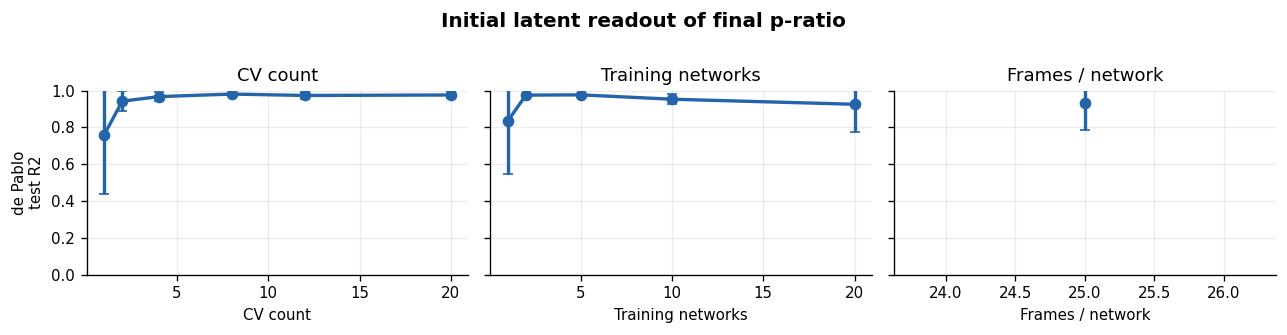

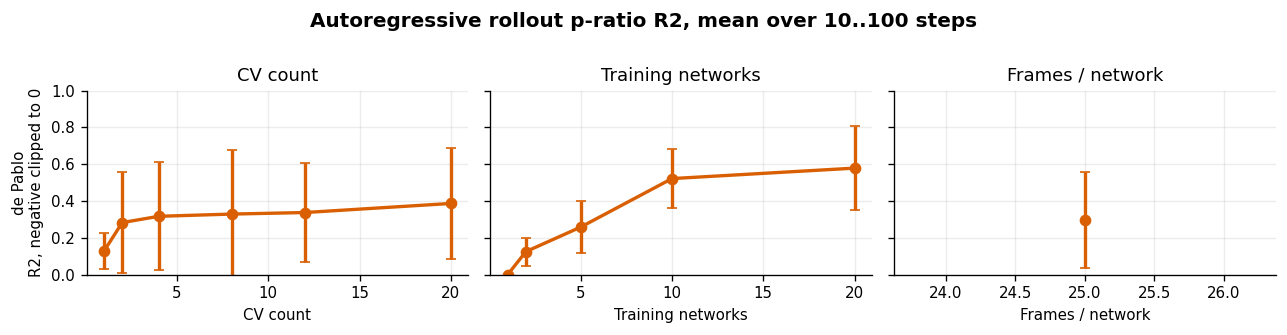

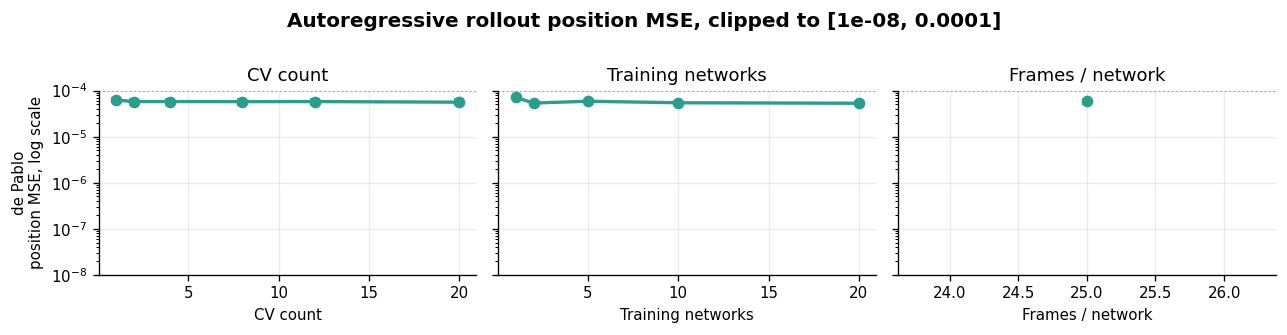

In [4]:
def plot_factor_grid(df, metric, *, title, ylabel, color, ylim=None, log_y=False, clip_errors=False):
    nrows = len(dataset_order)
    fig, axes = plt.subplots(nrows, 3, figsize=(10.8, 2.7 * nrows), sharey='row', squeeze=False)
    for row, dataset_name in enumerate(dataset_order):
        dataset_df = df[df['dataset_name'].eq(dataset_name)].copy()
        for col, (factor, label) in enumerate(plot_specs):
            ax = axes[row, col]
            grouped = dataset_df.groupby(factor).agg(mean=(metric, 'mean'), std=(metric, 'std')).reset_index().sort_values(factor)
            if grouped.empty:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
                continue
            if clip_errors:
                lower = np.maximum(grouped['mean'] - grouped['std'].fillna(0), mse_plot_floor)
                upper = np.minimum(grouped['mean'] + grouped['std'].fillna(0), mse_plot_cap)
                yerr = np.vstack([grouped['mean'] - lower, upper - grouped['mean']])
            else:
                yerr = grouped['std'].fillna(0)
            ax.errorbar(grouped[factor], grouped['mean'], yerr=yerr, marker='o', capsize=3, lw=2, color=color)
            if log_y:
                ax.set_yscale('log')
                ax.axhline(mse_plot_cap, color='0.35', lw=1, ls=':', alpha=0.7)
            if ylim is not None:
                ax.set_ylim(*ylim)
            if row == 0:
                ax.set_title(label)
            if row == nrows - 1:
                ax.set_xlabel(label)
            if col == 0:
                ax.set_ylabel(f"{dataset_labels.get(dataset_name, dataset_name)}\n{ylabel}")
    fig.suptitle(title, y=1.01, fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()

plot_factor_grid(
    initial_summary,
    'combo_test_r2_mean',
    title='Initial latent readout of final p-ratio',
    ylabel='test R2',
    color='#2364aa',
    ylim=(0, 1.0),
)

plot_factor_grid(
    rollout_config_summary,
    'mean_rollout_r2_clipped',
    title='Autoregressive rollout p-ratio R2, mean over 10..100 steps',
    ylabel='R2, negative clipped to 0',
    color='#d95f02',
    ylim=(0, 1.0),
)

plot_factor_grid(
    rollout_config_summary,
    'mean_position_mse_plot',
    title=f'Autoregressive rollout position MSE, clipped to [{mse_plot_floor:g}, {mse_plot_cap:g}]',
    ylabel='position MSE, log scale',
    color='#2a9d8f',
    ylim=(mse_plot_floor, mse_plot_cap),
    log_y=True,
    clip_errors=True,
)


In [5]:
def top_table(df, dataset_name, sort_col, ascending, cols, n=5):
    sub = df[df['dataset_name'].eq(dataset_name)].copy()
    return sub.sort_values(sort_col, ascending=ascending).head(n)[cols].round(6)

for dataset_name in dataset_order:
    label = dataset_labels.get(dataset_name, dataset_name)
    print(f'===== {label}: top 5 initial latent p-ratio readout =====')
    display(top_table(
        initial_summary,
        dataset_name,
        'combo_test_r2_mean',
        False,
        factors + ['combo_test_r2_mean', 'combo_test_r2_std', 'single_test_r2_mean', 'n_repeats'],
    ))

    print(f'===== {label}: top 5 rollout p-ratio R2, mean over 10..100 =====')
    display(top_table(
        rollout_config_summary,
        dataset_name,
        'mean_rollout_r2',
        False,
        factors + ['mean_rollout_r2', 'min_rollout_r2', 'step50_rollout_r2', 'step100_rollout_r2', 'mean_position_mse', 'n_repeats'],
    ))

    print(f'===== {label}: top 5 rollout position MSE, mean over 10..100; lower is better =====')
    display(top_table(
        rollout_config_summary,
        dataset_name,
        'mean_position_mse',
        True,
        factors + ['mean_position_mse', 'step50_position_mse', 'step100_position_mse', 'mean_rollout_r2', 'step100_rollout_r2', 'n_repeats'],
    ))

    print(f'===== {label}: top 5 rollout p-ratio R2 at exactly 50 steps =====')
    display(top_table(
        rollout_config_summary,
        dataset_name,
        'step50_rollout_r2',
        False,
        factors + ['step50_rollout_r2', 'step50_position_mse', 'mean_rollout_r2', 'mean_position_mse', 'n_repeats'],
    ))


===== de Pablo: top 5 initial latent p-ratio readout =====


,latent_dim,train_networks,train_frames_per_network,combo_test_r2_mean,combo_test_r2_std,single_test_r2_mean,n_repeats
9,2,20,25,0.987698,0.000721,0.986921,3
19,8,20,25,0.987557,0.001213,0.984304,3
15,8,1,25,0.987492,0.000227,0.882318,3
25,20,1,25,0.987396,0.000169,0.930912,3
20,12,1,25,0.987293,0.000134,0.850606,3


===== de Pablo: top 5 rollout p-ratio R2, mean over 10..100 =====


,latent_dim,train_networks,train_frames_per_network,mean_rollout_r2,min_rollout_r2,step50_rollout_r2,step100_rollout_r2,mean_position_mse,n_repeats
18,8,10,25,0.768180,0.334632,0.915364,0.460380,0.000187,3
29,20,20,25,0.706556,0.087903,0.910046,0.249987,0.000196,3
14,4,20,25,0.701847,0.286732,0.860368,0.355713,0.000343,3
24,12,20,25,0.633117,0.062345,0.875915,0.151534,0.000245,3
19,8,20,25,0.493101,-0.391024,0.820825,-0.203979,0.001141,3


===== de Pablo: top 5 rollout position MSE, mean over 10..100; lower is better =====


,latent_dim,train_networks,train_frames_per_network,mean_position_mse,step50_position_mse,step100_position_mse,mean_rollout_r2,step100_rollout_r2,n_repeats
26,20,2,25,0.000079,0.000028,0.000195,0.102907,-0.079081,3
11,4,2,25,0.000079,0.000031,0.000190,-0.484566,-1.304464,3
16,8,2,25,0.000092,0.000034,0.000223,-1.101883,-2.525782,3
21,12,2,25,0.000101,0.000032,0.000255,-0.124319,-1.127254,3
1,1,2,25,0.000101,0.000041,0.000241,-2.426018,-5.088135,3


===== de Pablo: top 5 rollout p-ratio R2 at exactly 50 steps =====


,latent_dim,train_networks,train_frames_per_network,step50_rollout_r2,step50_position_mse,mean_rollout_r2,mean_position_mse,n_repeats
18,8,10,25,0.915364,0.000019,0.768180,0.000187,3
29,20,20,25,0.910046,0.000018,0.706556,0.000196,3
24,12,20,25,0.875915,0.000018,0.633117,0.000245,3
14,4,20,25,0.860368,0.000020,0.701847,0.000343,3
19,8,20,25,0.820825,0.000028,0.493101,0.001141,3


## Best Rollout Curves

For each dataset, select five strong autoregressive rollout configurations with a simplicity preference. The selection first keeps configurations within `0.05` mean p-ratio R2 of the best configuration for that dataset, then prefers lower CV dimension, fewer training networks, and fewer frames per network. The plots show p-ratio R2 as a function of rollout step; tables list the corresponding summary metrics.


===== de Pablo: selected simple strong rollout configs =====


,latent_dim,train_networks,train_frames_per_network,mean_rollout_r2,min_rollout_r2,step50_rollout_r2,step100_rollout_r2,mean_position_mse,step50_position_mse,step100_position_mse,delta_from_best,n_repeats
0,4,20,25,0.701847,0.286732,0.860368,0.355713,0.000343,0.000020,0.000977,-0.066333,3
1,8,10,25,0.768180,0.334632,0.915364,0.460380,0.000187,0.000019,0.000527,0.000000,3
2,8,20,25,0.493101,-0.391024,0.820825,-0.203979,0.001141,0.000028,0.003188,-0.275079,3
3,12,20,25,0.633117,0.062345,0.875915,0.151534,0.000245,0.000018,0.000696,-0.135063,3
4,20,20,25,0.706556,0.087903,0.910046,0.249987,0.000196,0.000018,0.000551,-0.061624,3


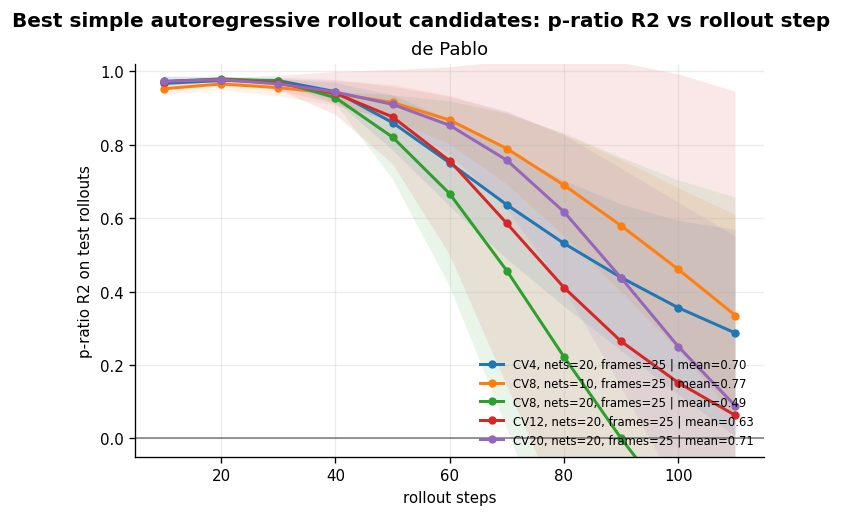

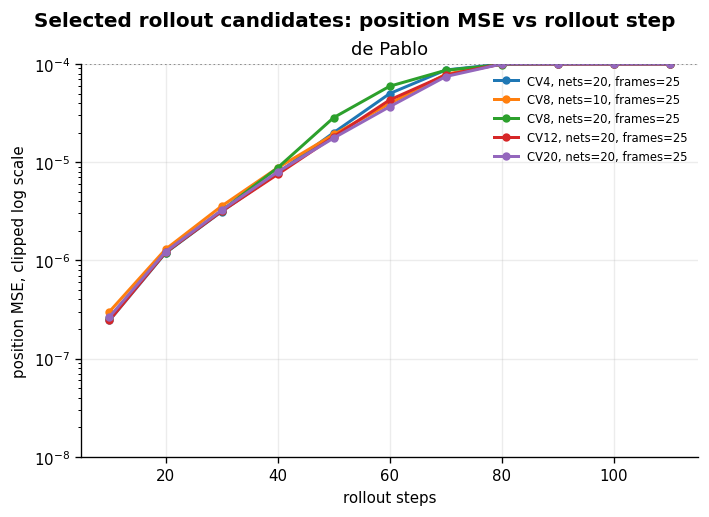

===== de Pablo: pure top 5 by mean rollout R2 =====


,latent_dim,train_networks,train_frames_per_network,mean_rollout_r2,min_rollout_r2,step50_rollout_r2,step100_rollout_r2,mean_position_mse,n_repeats
18,8,10,25,0.768180,0.334632,0.915364,0.460380,0.000187,3
29,20,20,25,0.706556,0.087903,0.910046,0.249987,0.000196,3
14,4,20,25,0.701847,0.286732,0.860368,0.355713,0.000343,3
24,12,20,25,0.633117,0.062345,0.875915,0.151534,0.000245,3
19,8,20,25,0.493101,-0.391024,0.820825,-0.203979,0.001141,3


In [6]:
# Best rollout candidates: strong performance with a simplicity preference.
selection_tolerance = 0.05
n_selected_rollouts = 5


def config_label(row):
    return f"CV{int(row['latent_dim'])}, nets={int(row['train_networks'])}, frames={int(row['train_frames_per_network'])}"


def select_simple_strong_rollouts(summary_df, dataset_name, *, n=5, tolerance=0.05):
    sub = summary_df[summary_df['dataset_name'].eq(dataset_name)].copy()
    if sub.empty:
        return sub
    best = float(sub['mean_rollout_r2'].max())
    strong = sub[sub['mean_rollout_r2'].ge(best - tolerance)].copy()
    strong = strong.sort_values(
        ['latent_dim', 'train_networks', 'train_frames_per_network', 'mean_rollout_r2'],
        ascending=[True, True, True, False],
    )
    selected = strong.head(n).copy()
    if len(selected) < n:
        selected_keys = set(map(tuple, selected[factors].to_numpy()))
        fill = sub[~sub[factors].apply(tuple, axis=1).isin(selected_keys)].sort_values('mean_rollout_r2', ascending=False)
        selected = pd.concat([selected, fill.head(n - len(selected))], ignore_index=True)
    selected['best_mean_rollout_r2'] = best
    selected['delta_from_best'] = selected['mean_rollout_r2'] - best
    selected['config_label'] = selected.apply(config_label, axis=1)
    return selected.sort_values(['latent_dim', 'train_networks', 'train_frames_per_network']).reset_index(drop=True)

selected_rollout_parts = []
for dataset_name in dataset_order:
    selected = select_simple_strong_rollouts(
        rollout_config_summary,
        dataset_name,
        n=n_selected_rollouts,
        tolerance=selection_tolerance,
    )
    selected_rollout_parts.append(selected)
    label = dataset_labels.get(dataset_name, dataset_name)
    print(f'===== {label}: selected simple strong rollout configs =====')
    display(selected[
        factors + [
            'mean_rollout_r2',
            'min_rollout_r2',
            'step50_rollout_r2',
            'step100_rollout_r2',
            'mean_position_mse',
            'step50_position_mse',
            'step100_position_mse',
            'delta_from_best',
            'n_repeats',
        ]
    ].round(6))

selected_rollouts = pd.concat(selected_rollout_parts, ignore_index=True) if selected_rollout_parts else pd.DataFrame()

fig, axes = plt.subplots(1, len(dataset_order), figsize=(5.8 * len(dataset_order), 4.2), sharey=True, squeeze=False, constrained_layout=True)
for ax, dataset_name in zip(axes[0], dataset_order):
    selected = selected_rollouts[selected_rollouts['dataset_name'].eq(dataset_name)].copy()
    ds_steps = rollout_step_summary[rollout_step_summary['dataset_name'].eq(dataset_name)].copy()
    for _, row in selected.iterrows():
        mask = np.ones(len(ds_steps), dtype=bool)
        for factor in factors:
            mask &= ds_steps[factor].eq(row[factor]).to_numpy()
        curve = ds_steps[mask].sort_values('rollout_steps')
        if curve.empty:
            continue
        label = f"{row['config_label']} | mean={row['mean_rollout_r2']:.2f}"
        ax.plot(curve['rollout_steps'], curve['rollout_p_ratio_r2_mean'], marker='o', lw=1.8, ms=4, label=label)
        y = curve['rollout_p_ratio_r2_mean'].to_numpy(dtype=float)
        yerr = curve['rollout_p_ratio_r2_std'].fillna(0).to_numpy(dtype=float)
        ax.fill_between(curve['rollout_steps'], y - yerr, y + yerr, alpha=0.10)
    ax.axhline(0.0, color='0.25', lw=0.9, alpha=0.7)
    ax.set_ylim(-0.05, 1.02)
    ax.set_xlabel('rollout steps')
    ax.set_title(dataset_labels.get(dataset_name, dataset_name))
    ax.grid(alpha=0.24)
    ax.legend(frameon=False, fontsize=7, loc='lower right')
axes[0, 0].set_ylabel('p-ratio R2 on test rollouts')
fig.suptitle('Best simple autoregressive rollout candidates: p-ratio R2 vs rollout step', fontsize=12, fontweight='bold')
plt.show()

# Same selected configs, position MSE versus rollout step on a clipped log scale.
fig, axes = plt.subplots(1, len(dataset_order), figsize=(5.8 * len(dataset_order), 4.2), sharey=True, squeeze=False, constrained_layout=True)
for ax, dataset_name in zip(axes[0], dataset_order):
    selected = selected_rollouts[selected_rollouts['dataset_name'].eq(dataset_name)].copy()
    ds_steps = rollout_step_summary[rollout_step_summary['dataset_name'].eq(dataset_name)].copy()
    for _, row in selected.iterrows():
        mask = np.ones(len(ds_steps), dtype=bool)
        for factor in factors:
            mask &= ds_steps[factor].eq(row[factor]).to_numpy()
        curve = ds_steps[mask].sort_values('rollout_steps')
        if curve.empty:
            continue
        mse = curve['rollout_position_mse_plot_mean'].clip(lower=mse_plot_floor, upper=mse_plot_cap)
        ax.plot(curve['rollout_steps'], mse, marker='o', lw=1.8, ms=4, label=row['config_label'])
    ax.set_yscale('log')
    ax.set_ylim(mse_plot_floor, mse_plot_cap)
    ax.axhline(mse_plot_cap, color='0.35', lw=1, ls=':', alpha=0.75)
    ax.set_xlabel('rollout steps')
    ax.set_title(dataset_labels.get(dataset_name, dataset_name))
    ax.grid(alpha=0.24)
    ax.legend(frameon=False, fontsize=7, loc='best')
axes[0, 0].set_ylabel('position MSE, clipped log scale')
fig.suptitle('Selected rollout candidates: position MSE vs rollout step', fontsize=12, fontweight='bold')
plt.show()

# Reference: pure top-5 by mean rollout R2, without simplicity preference.
for dataset_name in dataset_order:
    label = dataset_labels.get(dataset_name, dataset_name)
    print(f'===== {label}: pure top 5 by mean rollout R2 =====')
    display(
        rollout_config_summary[rollout_config_summary['dataset_name'].eq(dataset_name)]
        .sort_values('mean_rollout_r2', ascending=False)
        .head(5)[factors + ['mean_rollout_r2', 'min_rollout_r2', 'step50_rollout_r2', 'step100_rollout_r2', 'mean_position_mse', 'n_repeats']]
        .round(6)
    )


In [7]:
# Optional compact numeric marginals for paper notes.
def marginal_table(df, metric):
    rows = []
    for dataset_name in dataset_order:
        sub = df[df['dataset_name'].eq(dataset_name)]
        for factor in factors:
            part = sub.groupby(factor)[metric].mean().reset_index()
            part.insert(0, 'dataset_name', dataset_name)
            part.insert(1, 'factor', factor)
            part = part.rename(columns={factor: 'value', metric: 'mean_metric'})
            rows.append(part)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

print('Initial readout R2 marginals')
display(marginal_table(initial_summary, 'combo_test_r2_mean').round(4))
print('Rollout p-ratio R2 marginals')
display(marginal_table(rollout_config_summary, 'mean_rollout_r2_clipped').round(4))
print('Rollout position MSE marginals, clipped for plotting')
display(marginal_table(rollout_config_summary, 'mean_position_mse_plot').round(8))


Initial readout R2 marginals


,dataset_name,factor,value,mean_metric
0,depablo,latent_dim,1,0.7574
1,depablo,latent_dim,2,0.9424
2,depablo,latent_dim,4,0.9673
3,depablo,latent_dim,8,0.9811
4,depablo,latent_dim,12,0.9735
5,depablo,latent_dim,20,0.9762
6,depablo,train_networks,1,0.8338
7,depablo,train_networks,2,0.9755
8,depablo,train_networks,5,0.9768
9,depablo,train_networks,10,0.9533


Rollout p-ratio R2 marginals


,dataset_name,factor,value,mean_metric
0,depablo,latent_dim,1,0.1277
1,depablo,latent_dim,2,0.2830
2,depablo,latent_dim,4,0.3171
3,depablo,latent_dim,8,0.3292
4,depablo,latent_dim,12,0.3376
5,depablo,latent_dim,20,0.3869
6,depablo,train_networks,1,0.0000
7,depablo,train_networks,2,0.1252
8,depablo,train_networks,5,0.2584
9,depablo,train_networks,10,0.5220


Rollout position MSE marginals, clipped for plotting


,dataset_name,factor,value,mean_metric
0,depablo,latent_dim,1,0.000062
1,depablo,latent_dim,2,0.000058
2,depablo,latent_dim,4,0.000058
3,depablo,latent_dim,8,0.000058
4,depablo,latent_dim,12,0.000058
5,depablo,latent_dim,20,0.000056
6,depablo,train_networks,1,0.000071
7,depablo,train_networks,2,0.000054
8,depablo,train_networks,5,0.000059
9,depablo,train_networks,10,0.000054
